# 3 · Points, cells & vector fields

Beyond continuous fields, `Map` renders **discrete geometry** and **vector fields**:

- `grid_points` / `point_cloud` — raster cell centres as a coloured scatter (cleopatra `ScatterGlyph`).
- `grid_cells` — one coloured polygon per cell (cleopatra `PolygonGlyph`).
- `scatter` — an arbitrary `FeatureCollection` of points.
- `quiver` / `barbs` / `streamplot` — a vector field from two rasters `(u, v)` (cleopatra `VectorGlyph`).

Markers/polygons get unreadable at full resolution, so the DEM is **resampled coarser** (via pyramids) for these demos, and the vector field is the DEM's own gradient (arrows point downhill).

**Setup.** Inline plots + resolve the DEM path.

In [1]:
%matplotlib inline
from pathlib import Path

# Resolve the repo root so the bundled sample DEM is found whether this runs from
# docs/examples/ (mkdocs) or the repository root.
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
print("DEM:", DEM)

DEM: C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\examples\data\LisbonElevation.tif


Read the DEM and **resample it coarser** (×8 cell size) via pyramids, so the per-cell points and polygons below stay legible instead of being thousands of overlapping markers.

In [2]:
import numpy as np
from pyramids.dataset import Dataset, GeoReference
from digitalearth.scene import Map

ds = Dataset.read_file(DEM)
coarse = ds.resample(ds.cell_size * 8)   # ~53x68 cells -> legible points/cells
print('coarse grid:', coarse.rows, 'x', coarse.columns)

coarse grid: 53 x 68


## grid_points — cell centres coloured by elevation

**grid_points** — plot each cell centre as a point coloured by its elevation (cleopatra `ScatterGlyph`). pyramids' `to_xyz` provides the point coordinates and values.

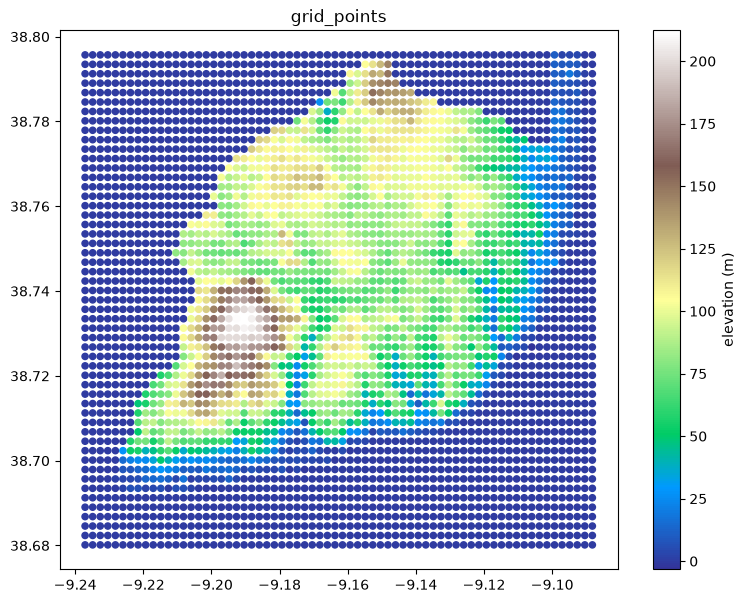

In [3]:
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.grid_points(coarse, cmap='terrain')
m.colorbar(label='elevation (m)')
m.set_title('grid_points')
m.fig;

## grid_cells — one coloured polygon per cell

**grid_cells** — draw one filled polygon per raster cell (cleopatra `PolygonGlyph`), coloured by elevation; the polygons come from pyramids' `get_cell_polygons`.

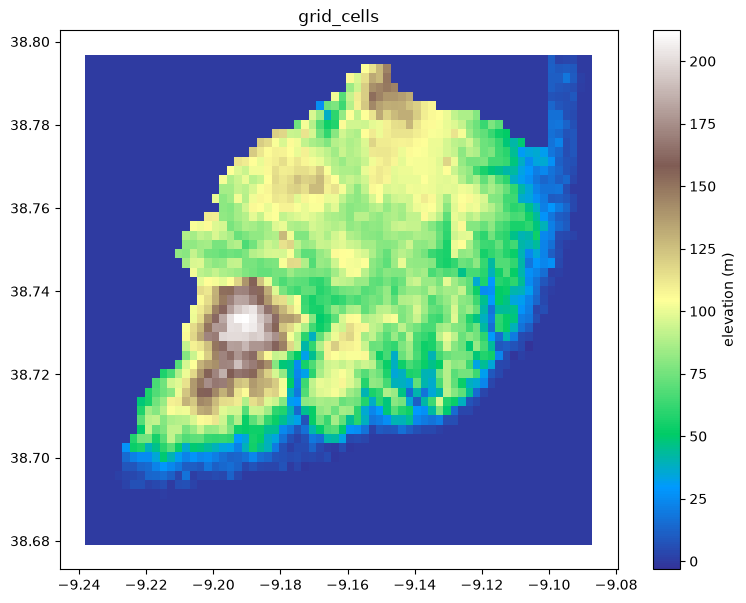

In [4]:
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.grid_cells(coarse, cmap='terrain')
m.colorbar(label='elevation (m)')
m.set_title('grid_cells')
m.fig;

## Vector field — quiver / streamplot from the DEM gradient

The terrain slope (−∇elevation) makes a natural vector field: arrows point downhill.

Build a **vector field** from the terrain: the negative gradient of elevation points downhill. We wrap the two components as pyramids `Dataset`s (`u`, `v`) on the coarse grid.

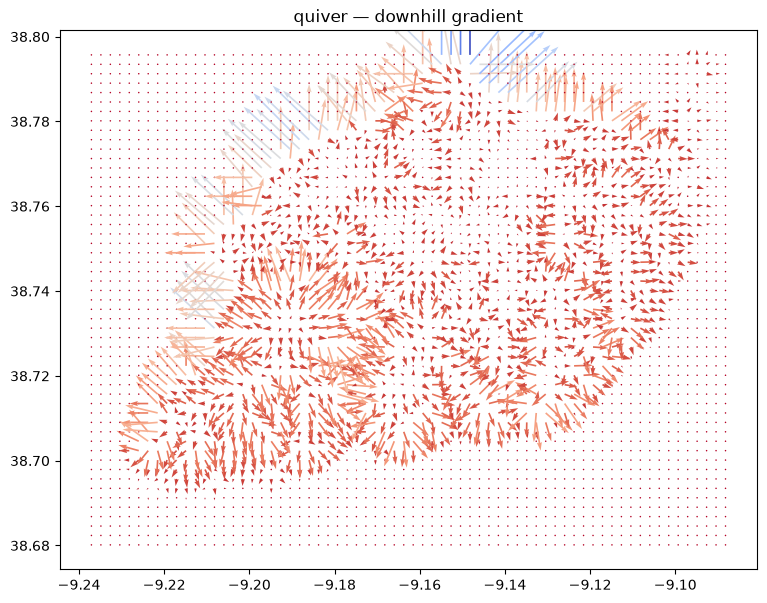

In [5]:
z = np.nan_to_num(coarse.read_array(band=0).astype('float32'))
dy, dx = np.gradient(z)
geo = coarse.geotransform
u = Dataset.from_array(arr=(-dx).astype('float32'), geo_ref=GeoReference(geo=geo, epsg=coarse.epsg))
v = Dataset.from_array(arr=(dy).astype('float32'), geo_ref=GeoReference(geo=geo, epsg=coarse.epsg))
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.quiver(u, v)
m.set_title('quiver — downhill gradient')
m.fig;

**quiver** then **streamplot** render that `(u, v)` field via cleopatra `VectorGlyph` — arrows and flow lines coloured by magnitude. (`streamplot` needs strictly-increasing axes, which `Map` handles by flipping the north→south raster rows.)

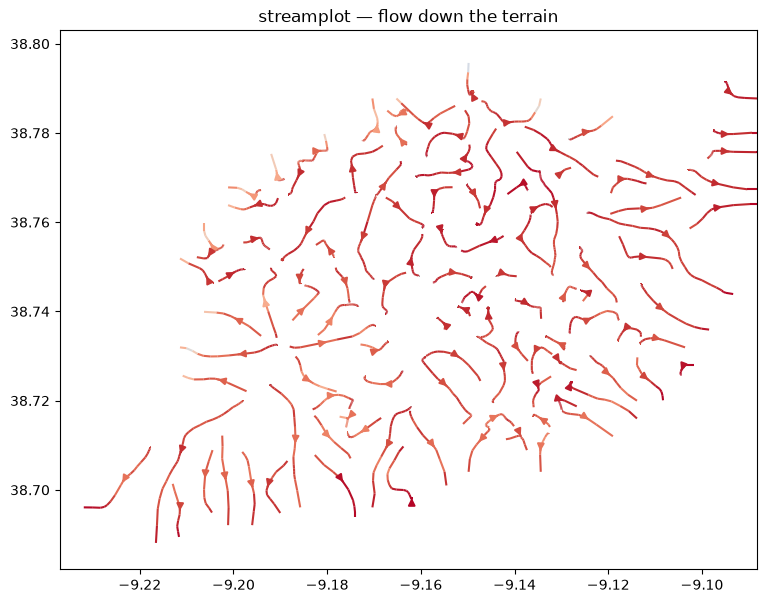

In [6]:
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.streamplot(u, v)
m.set_title('streamplot — flow down the terrain')
m.fig;